# Deep learning Monograph - BraTS model runner

In [ ]:
# @title Mount drive

from google.colab import userdata
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

In [ ]:
# @title Get repository
%cd /content/drive/MyDrive/Monograph
!git clone https://github.com/maxogod/DeepLearningMonograph
%cd /content/drive/MyDrive/Monograph/DeepLearningMonograph
!git stash
!git pull
!ls

In [ ]:
%cd /content/drive/MyDrive/Monograph/DeepLearningMonograph

In [ ]:
# @title CAREFUL! Get training data (only once)

ans = input("Are you sure you want to re-unzip the data? (y/n): ")

if ans.lower() == "y":
    %cd /content/drive/MyDrive/Monograph/
    !unzip ./preproc.zip
    !mkdir -p ./DeepLearningMonograph/data
    !mv preproc ./DeepLearningMonograph/data/preproc
else:
    print("Skipped.")

%cd /content/drive/MyDrive/Monograph/DeepLearningMonograph

In [ ]:
# @title Imports

!pip install torchinfo
!pip install monai==1.5.1
!pip install torchio==0.21.1
!pip install simpleitk==2.5.3
!pip install nibabel==5.3.3
!pip install seaborn==0.13.2
!pip install pandas==2.3.3
!pip install tqdm==4.67.1
!pip install split-folders
!pip install torchinfo

In [ ]:
# @title GPU stats

!nvidia-smi

Tue Apr  7 14:59:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# @title Show config

!python -m src.config.config

Config(
  environment=development,
  random_seed=42,
  loader_workers=2,
  max_files_cached=1,
  preprocessing_config=PreprocessingConfig(print_class_imbalance=False, preprocess=False, split_ratio=0.8, plot_lr_evolution=False),
  train_config=TrainConfig(train=False, resume_training=True, resume_from='trained_models/best_annealing.pth', batch_size=8, num_epochs=150, learning_rate=0.0001, eta_min_lr=9e-05, weighted_loss=True, save_model=True, model_name='annealing_3.pth', loss_history_path='models/loss_history/'),
  validation_config=ValidationConfig(model_path='trained_models/best_new_model_2.pth', ensemble=False, ensemble_models=['trained_models/best_annealing_3.pth', 'trained_models/best_new_model_2.pth', 'trained_models/best_model_weighted.pth'], evaluate=False, predict=True, plot_loss=False, batch_size=1),
  file_paths=FilePaths(raw_data='data/raw/training/', preproc_data='data/preproc/', model_save_path='models/')
)


In [ ]:
# @title Train

!python -m src.main

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-07 15:03:27.317425: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775574207.507250    8493 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775574207.562715    8493 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775574207.992209    8493 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775574207.992251    8493 computation_placer.cc:1

In [ ]:
# @title Eval

!python -m src.main

2026-06-30 01:03:00.776113: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-30 01:03:00.852862: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-30 01:03:05,727 | INFO | src.utils.logger | Starting evaluation...
2026-06-30 01:03:06,479 | DEBUG | src.utils.logger | Found 63 volume files and 63 segmentation files.
2026-06-30 01:03:06,480 | INFO | src.utils.logger | Using single model for evaluation: trained_models/best_new_model_2.pth
2026-06-30 01:03:06,804 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_new_model_2.pth with epochs: 168
100% 63/63 [34:40<00:00, 33.02s/it]
2026-06-30 01:37:47,325 | INFO | src.utils.logger | Per-class IoU (NCR, ED,

In [ ]:
# @title Predict

from os import path
import sys
import torch
from torch import optim, amp
from torch.utils.data import DataLoader
from src.preprocessing.class_imbalance import measure_class_inbalance
from src.preprocessing.lr_evolution import plot_learning_rate_evolution
from src.utils import file_operations
from src.utils.device import get_device_type
from src.utils.consts import (
    PREPROC_TEST,
    PREPROC_TRAIN,
)
import src.utils.logger as logger
from src.config.config import Config
from src.preprocessing.preprocessor import Preprocessor
from src.models.unet_3d import UNet3D
from src.training.loss_functions import WeightedDiceFocalLoss
from src.training.train import Trainer
from src.inference.evaluator import Evaluator
from src.inference.predictor import Predictor
from src.inference.ensemble_predictor import EnsemblePredictor
from src.inference.plotter import InferencePlotter
from src.dataset.brats_dataset import BraTSDataset
from src.utils.loss_plotter import plot_loss_history

def predict(config: Config, rmi_folder: str):
    log = logger.get_logger()

    # Load model
    model_state_dict, _, _, _ = file_operations.load_torch(
        config.validation_config.model_path
    )
    model = UNet3D(in_channels=3, num_classes=4)
    model.load_state_dict(model_state_dict)

    predictor = Predictor(model)
    x, volume, seg_onehot, files = predictor.prepare_from_rmi_folder(rmi_folder)
    log.info(f"T1CE: {files['t1ce']}")
    log.info(f"T2:   {files['t2']}")
    log.info(f"FLAIR:{files['flair']}")
    log.info(f"SEG:  {files['seg']}")

    preds = predictor.predict_single_image(x)

    plotter = InferencePlotter()
    plotter.plot_prediction(volume=volume, seg_onehot=seg_onehot, preds=preds)

def main():
    config = Config()
    logger.setup_logging(config.environment)
    log = logger.get_logger()
    torch.manual_seed(config.random_seed)

    folders = [
        "data/raw/training/BraTS20_Training_010",
        "data/raw/training/BraTS20_Training_023",
        "data/raw/training/BraTS20_Training_068",
        "data/raw/training/BraTS20_Training_264",
        "data/raw/training/BraTS20_Training_273",
        "data/raw/training/BraTS20_Training_324",
        "data/raw/training/BraTS20_Training_327",
        "data/raw/training/BraTS20_Training_342",
        "data/raw/training/BraTS20_Training_351",
    ]
    for rmi_folder in folders:
      log.info(f"Starting prediction on RMI folder: {rmi_folder}")
      predict(config, rmi_folder)

2026-06-30 02:00:06,648 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_010
2026-06-30 02:00:06,823 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_new_model_2.pth with epochs: 168
2026-06-30 02:00:13,356 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_010/BraTS20_Training_010_t1ce.nii
2026-06-30 02:00:13,358 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_010/BraTS20_Training_010_t2.nii
2026-06-30 02:00:13,359 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_010/BraTS20_Training_010_flair.nii
2026-06-30 02:00:13,360 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_010/BraTS20_Training_010_seg.nii


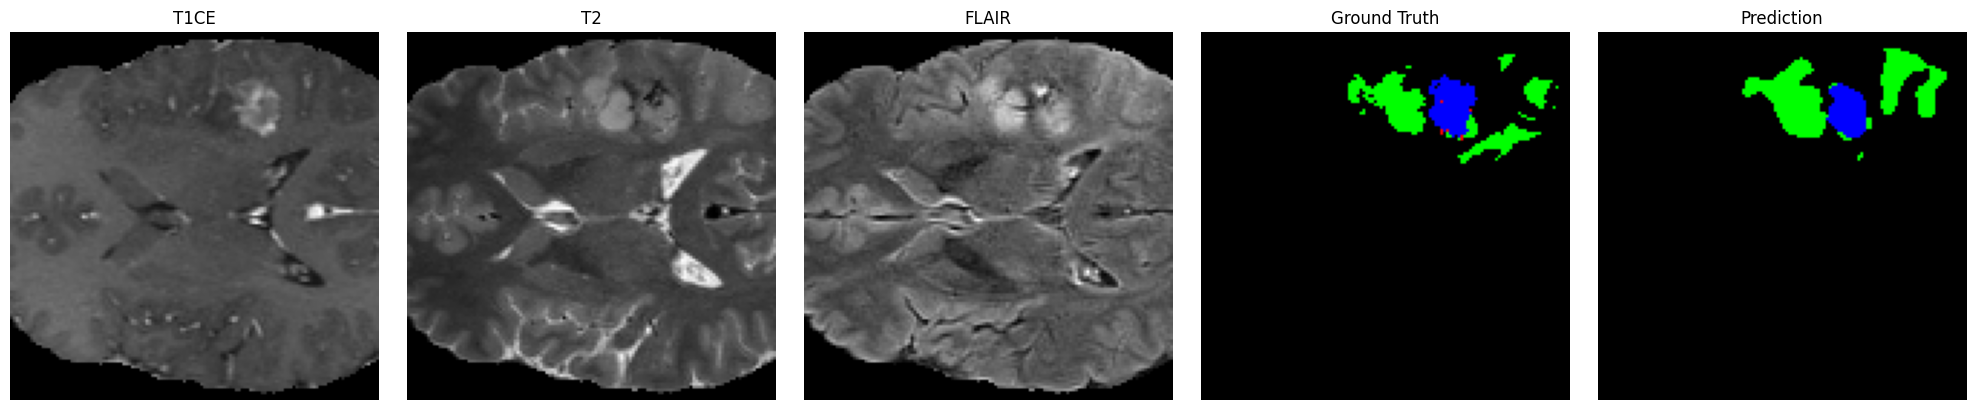

2026-06-30 02:00:23,830 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_023
2026-06-30 02:00:24,085 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_new_model_2.pth with epochs: 168
2026-06-30 02:00:30,317 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_023/BraTS20_Training_023_t1ce.nii
2026-06-30 02:00:30,318 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_023/BraTS20_Training_023_t2.nii
2026-06-30 02:00:30,319 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_023/BraTS20_Training_023_flair.nii
2026-06-30 02:00:30,320 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_023/BraTS20_Training_023_seg.nii


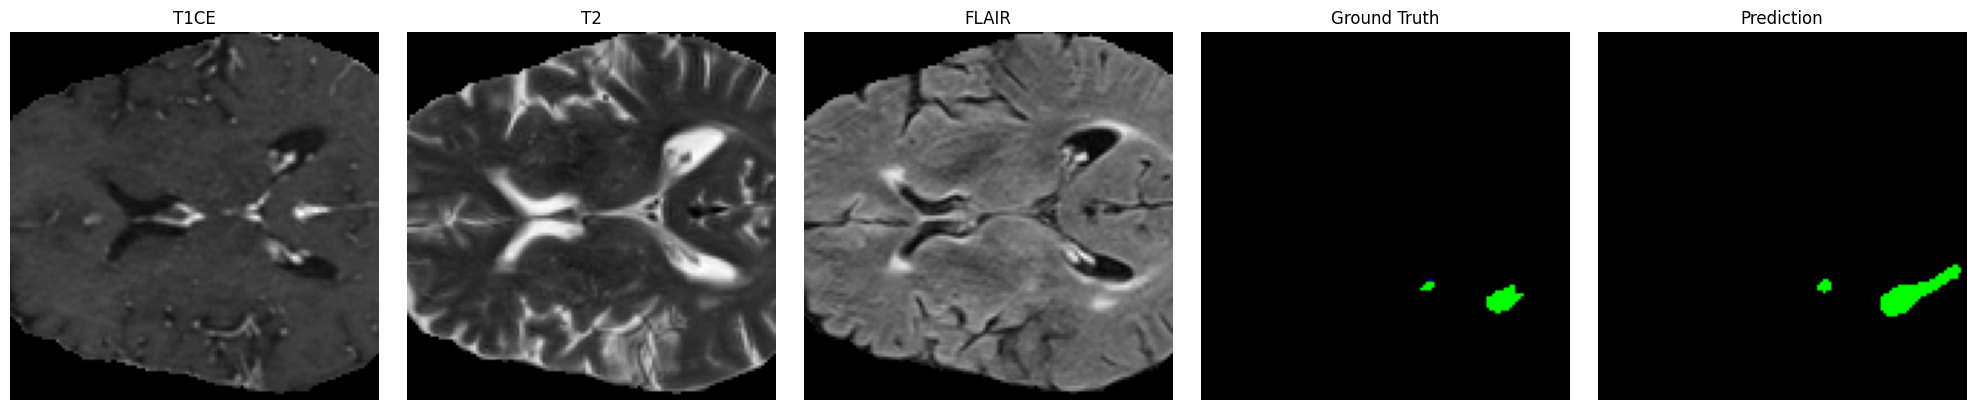

2026-06-30 02:00:40,880 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_068
2026-06-30 02:00:41,190 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_new_model_2.pth with epochs: 168
2026-06-30 02:00:50,770 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_068/BraTS20_Training_068_t1ce.nii
2026-06-30 02:00:50,771 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_068/BraTS20_Training_068_t2.nii
2026-06-30 02:00:50,773 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_068/BraTS20_Training_068_flair.nii
2026-06-30 02:00:50,774 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_068/BraTS20_Training_068_seg.nii


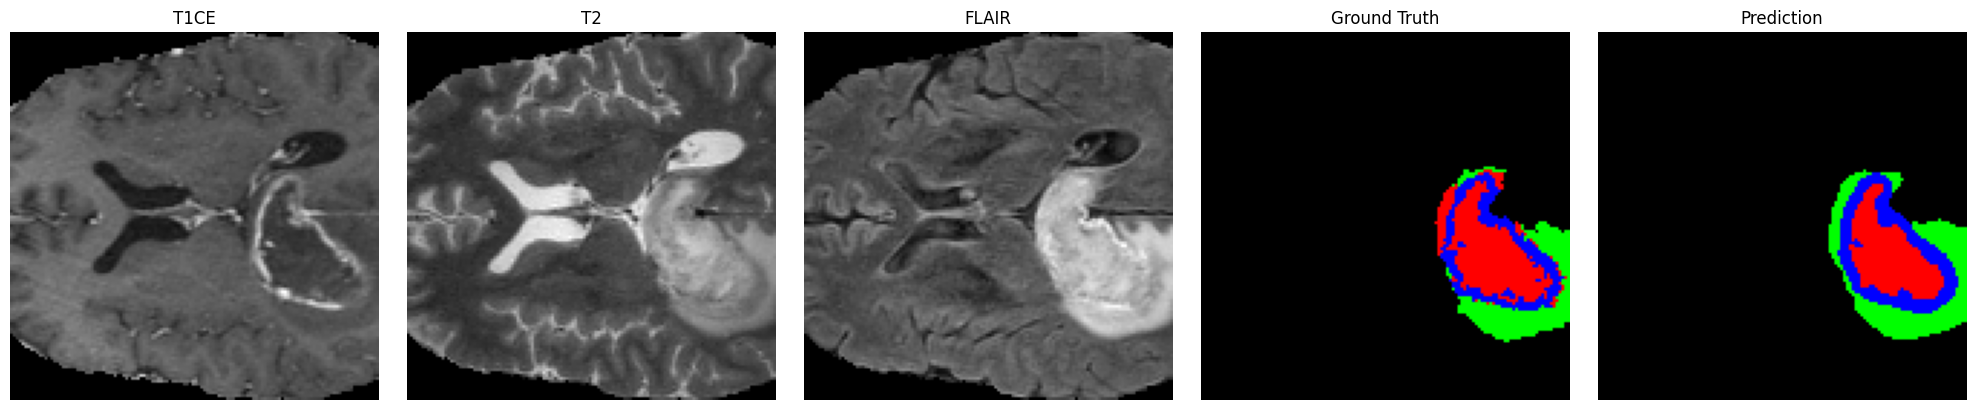

2026-06-30 02:01:01,368 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_264
2026-06-30 02:01:01,570 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_new_model_2.pth with epochs: 168
2026-06-30 02:01:07,482 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_264/BraTS20_Training_264_t1ce.nii
2026-06-30 02:01:07,483 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_264/BraTS20_Training_264_t2.nii
2026-06-30 02:01:07,485 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_264/BraTS20_Training_264_flair.nii
2026-06-30 02:01:07,486 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_264/BraTS20_Training_264_seg.nii


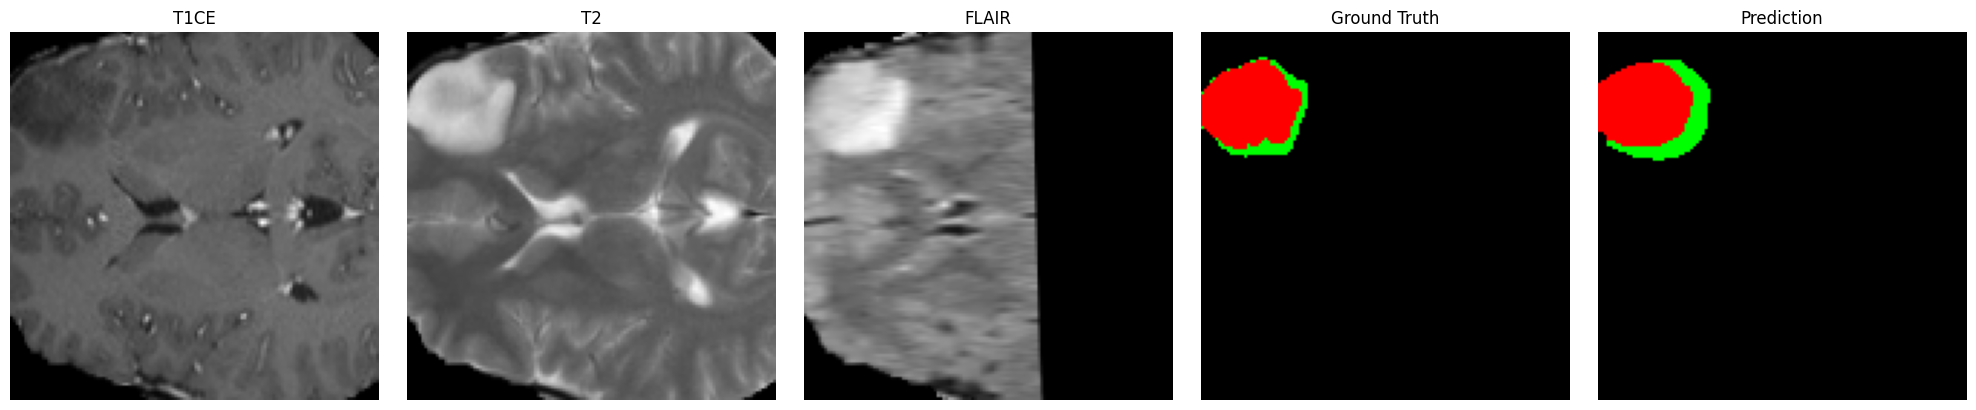

2026-06-30 02:01:18,066 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_273
2026-06-30 02:01:18,240 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_new_model_2.pth with epochs: 168
2026-06-30 02:01:24,406 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_273/BraTS20_Training_273_t1ce.nii
2026-06-30 02:01:24,409 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_273/BraTS20_Training_273_t2.nii
2026-06-30 02:01:24,411 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_273/BraTS20_Training_273_flair.nii
2026-06-30 02:01:24,413 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_273/BraTS20_Training_273_seg.nii


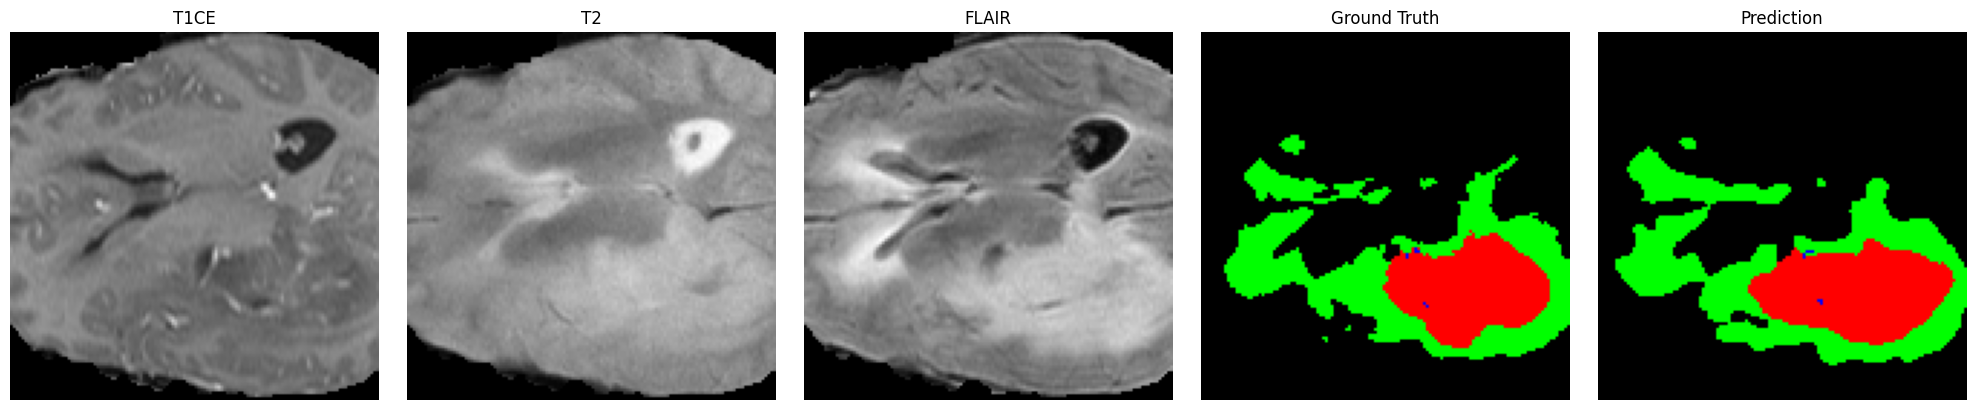

2026-06-30 02:01:34,184 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_324
2026-06-30 02:01:34,369 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_new_model_2.pth with epochs: 168
2026-06-30 02:01:35,633 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_324/BraTS20_Training_324_t1ce.nii
2026-06-30 02:01:35,634 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_324/BraTS20_Training_324_t2.nii
2026-06-30 02:01:35,635 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_324/BraTS20_Training_324_flair.nii
2026-06-30 02:01:35,637 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_324/BraTS20_Training_324_seg.nii


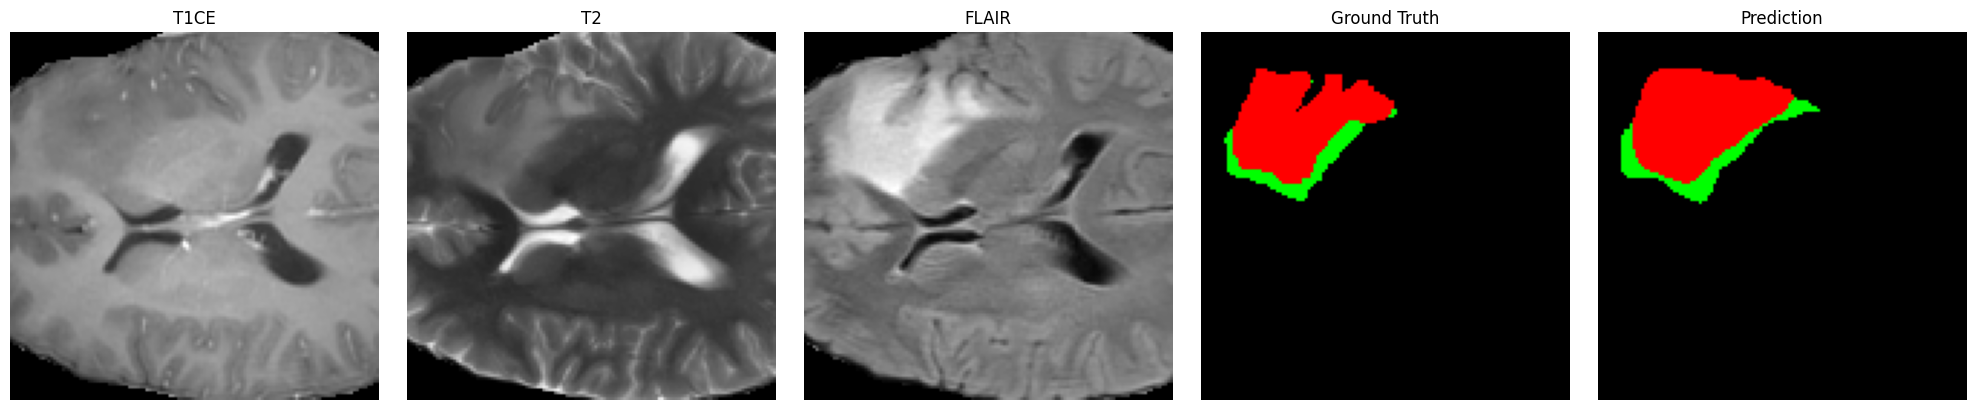

2026-06-30 02:01:46,016 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_327
2026-06-30 02:01:46,237 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_new_model_2.pth with epochs: 168
2026-06-30 02:01:53,156 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_327/BraTS20_Training_327_t1ce.nii
2026-06-30 02:01:53,158 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_327/BraTS20_Training_327_t2.nii
2026-06-30 02:01:53,158 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_327/BraTS20_Training_327_flair.nii
2026-06-30 02:01:53,159 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_327/BraTS20_Training_327_seg.nii


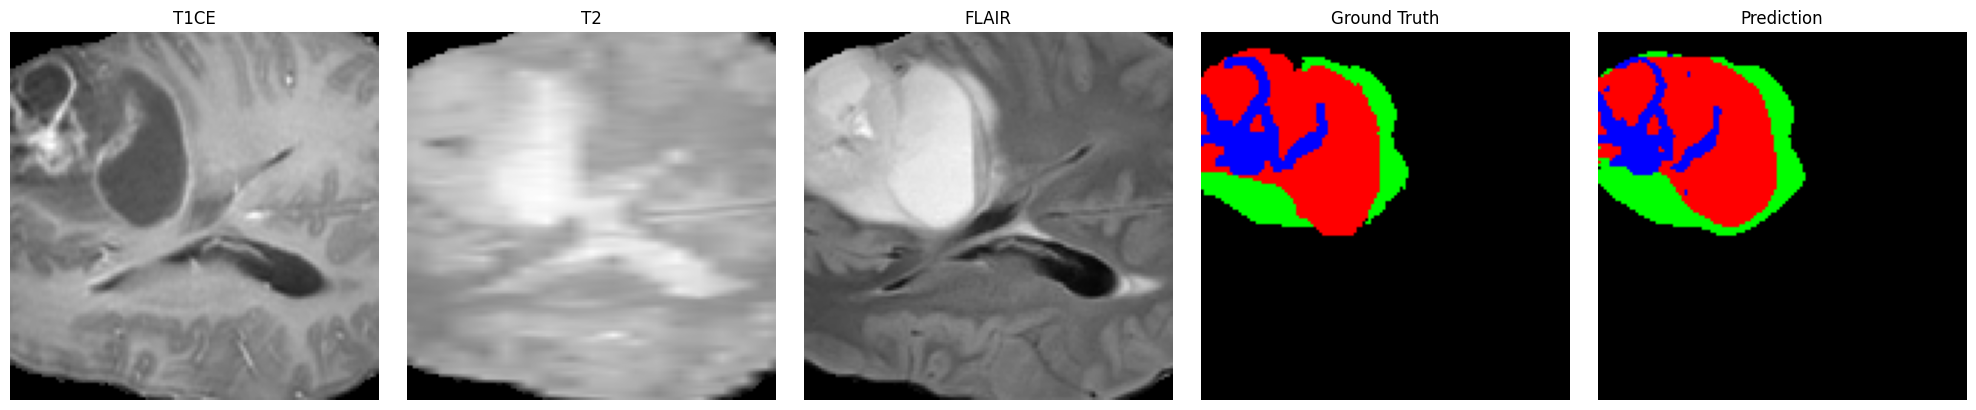

2026-06-30 02:02:03,961 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_342
2026-06-30 02:02:04,165 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_new_model_2.pth with epochs: 168
2026-06-30 02:02:11,912 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_342/BraTS20_Training_342_t1ce.nii
2026-06-30 02:02:11,924 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_342/BraTS20_Training_342_t2.nii
2026-06-30 02:02:11,930 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_342/BraTS20_Training_342_flair.nii
2026-06-30 02:02:11,932 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_342/BraTS20_Training_342_seg.nii


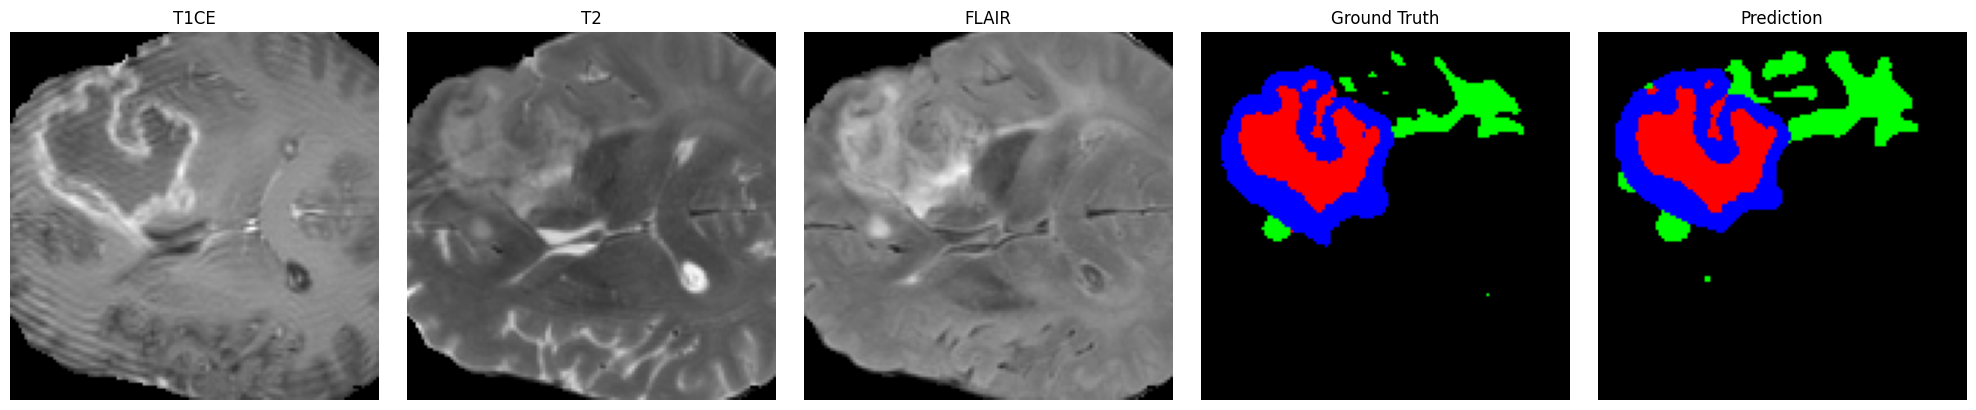

2026-06-30 02:02:31,740 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_351
2026-06-30 02:02:31,937 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_new_model_2.pth with epochs: 168
2026-06-30 02:02:39,317 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_351/BraTS20_Training_351_t1ce.nii
2026-06-30 02:02:39,318 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_351/BraTS20_Training_351_t2.nii
2026-06-30 02:02:39,319 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_351/BraTS20_Training_351_flair.nii
2026-06-30 02:02:39,321 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_351/BraTS20_Training_351_seg.nii


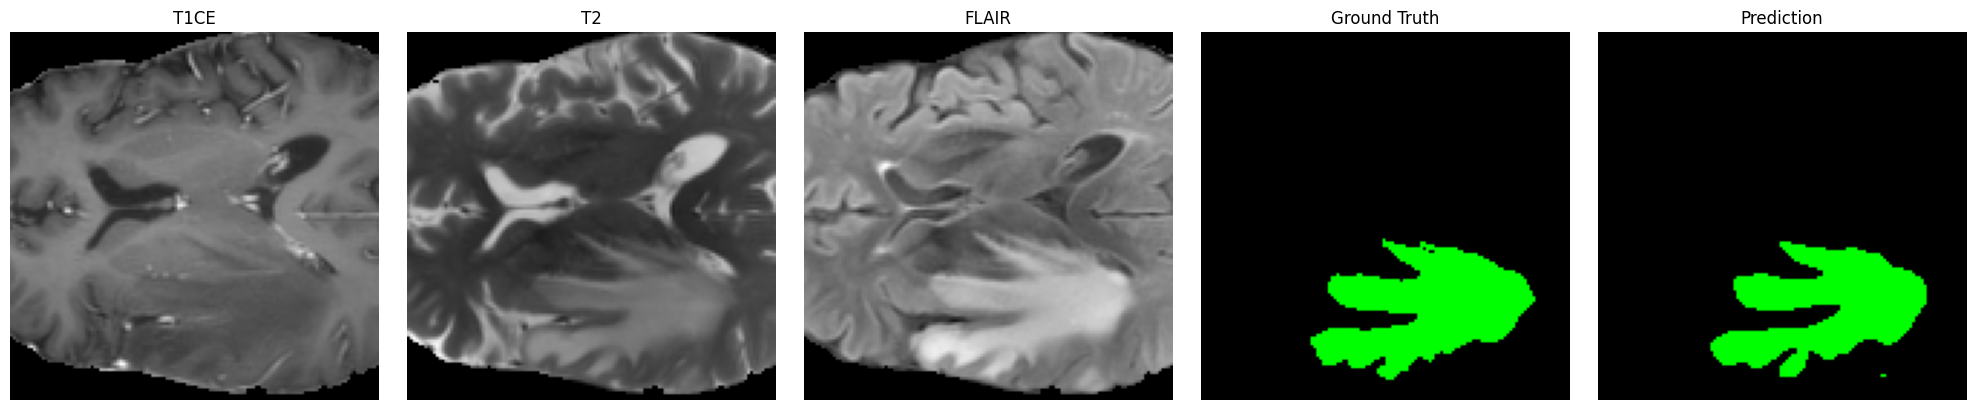

In [ ]:
# @title Predict - Best

main()

2026-06-30 16:38:57,391 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_010
2026-06-30 16:38:59,518 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_annealing_3.pth with epochs: 133
2026-06-30 16:39:04,387 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_010/BraTS20_Training_010_t1ce.nii
2026-06-30 16:39:04,389 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_010/BraTS20_Training_010_t2.nii
2026-06-30 16:39:04,389 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_010/BraTS20_Training_010_flair.nii
2026-06-30 16:39:04,390 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_010/BraTS20_Training_010_seg.nii
2026-06-30 16:39:13,196 | DEBUG | matplotlib.font_manager | findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-30 16:39:13,198 | DEBUG | matplotlib.font_manager | findfont: score(Font

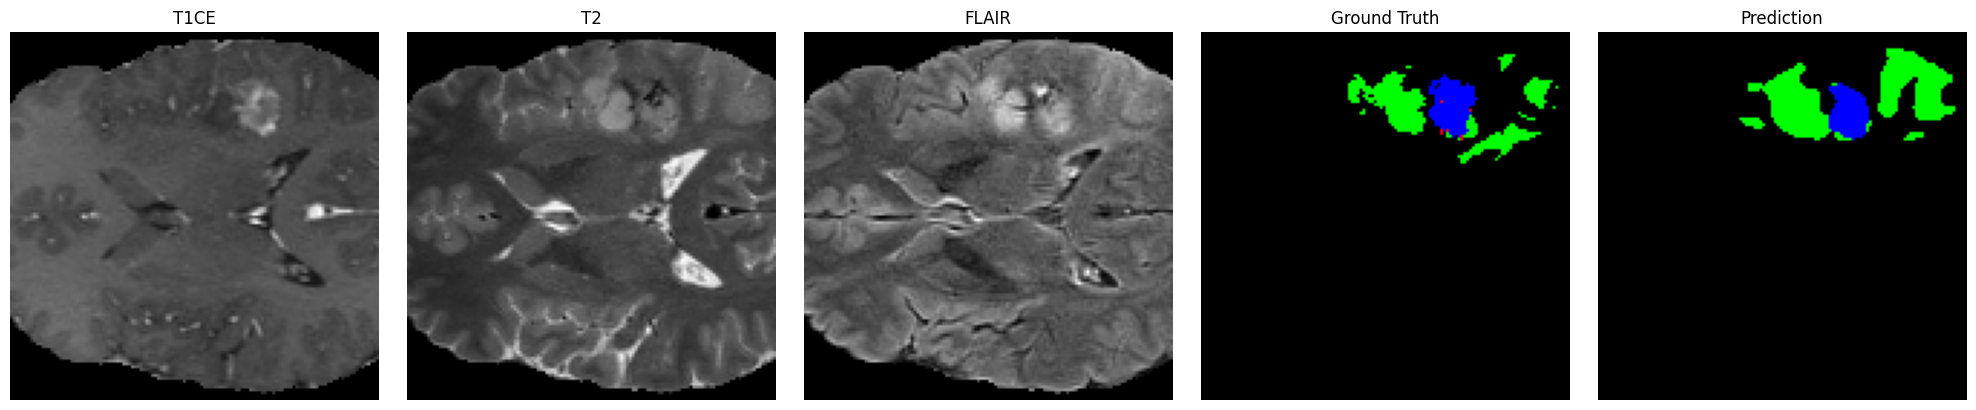

2026-06-30 16:39:13,967 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_023
2026-06-30 16:39:14,127 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_annealing_3.pth with epochs: 133
2026-06-30 16:39:18,626 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_023/BraTS20_Training_023_t1ce.nii
2026-06-30 16:39:18,628 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_023/BraTS20_Training_023_t2.nii
2026-06-30 16:39:18,630 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_023/BraTS20_Training_023_flair.nii
2026-06-30 16:39:18,630 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_023/BraTS20_Training_023_seg.nii


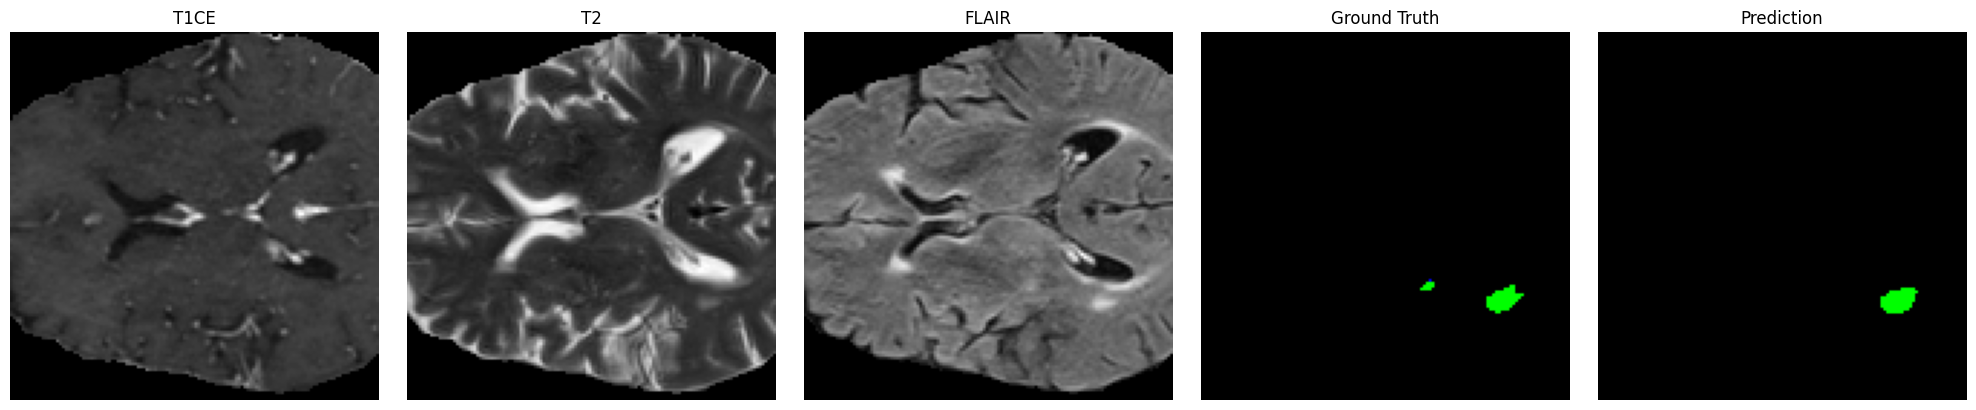

2026-06-30 16:39:27,937 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_068
2026-06-30 16:39:28,091 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_annealing_3.pth with epochs: 133
2026-06-30 16:39:33,218 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_068/BraTS20_Training_068_t1ce.nii
2026-06-30 16:39:33,220 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_068/BraTS20_Training_068_t2.nii
2026-06-30 16:39:33,220 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_068/BraTS20_Training_068_flair.nii
2026-06-30 16:39:33,221 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_068/BraTS20_Training_068_seg.nii


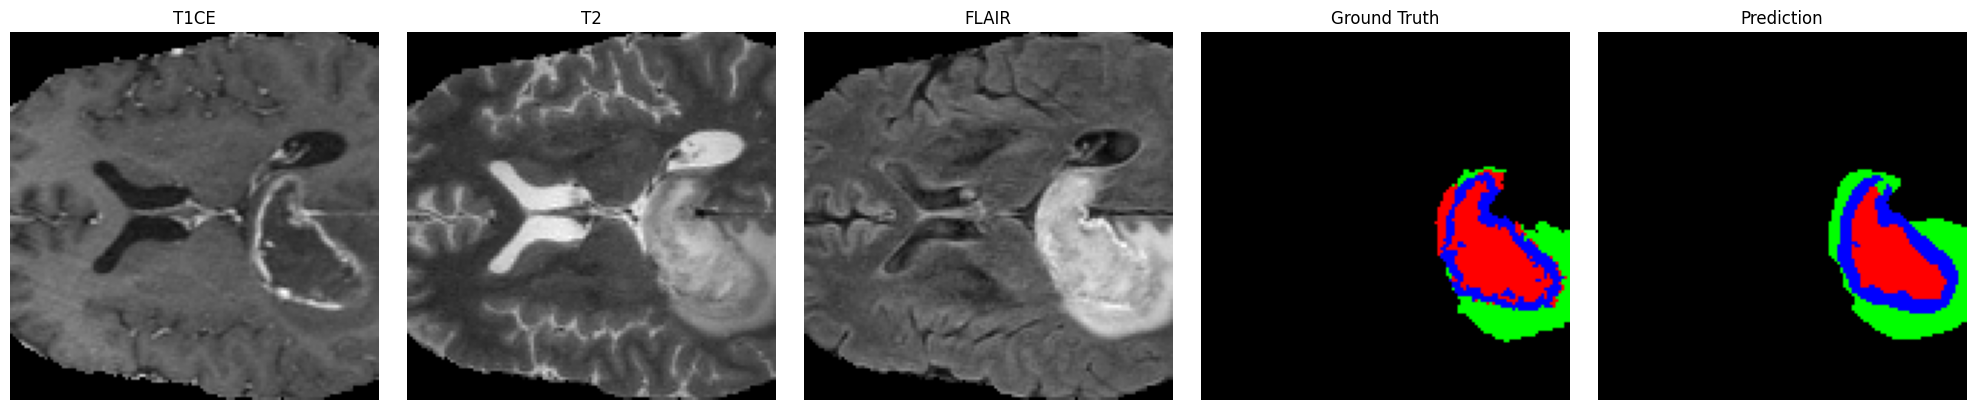

2026-06-30 16:39:43,653 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_264
2026-06-30 16:39:43,838 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_annealing_3.pth with epochs: 133
2026-06-30 16:39:48,043 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_264/BraTS20_Training_264_t1ce.nii
2026-06-30 16:39:48,044 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_264/BraTS20_Training_264_t2.nii
2026-06-30 16:39:48,046 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_264/BraTS20_Training_264_flair.nii
2026-06-30 16:39:48,047 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_264/BraTS20_Training_264_seg.nii


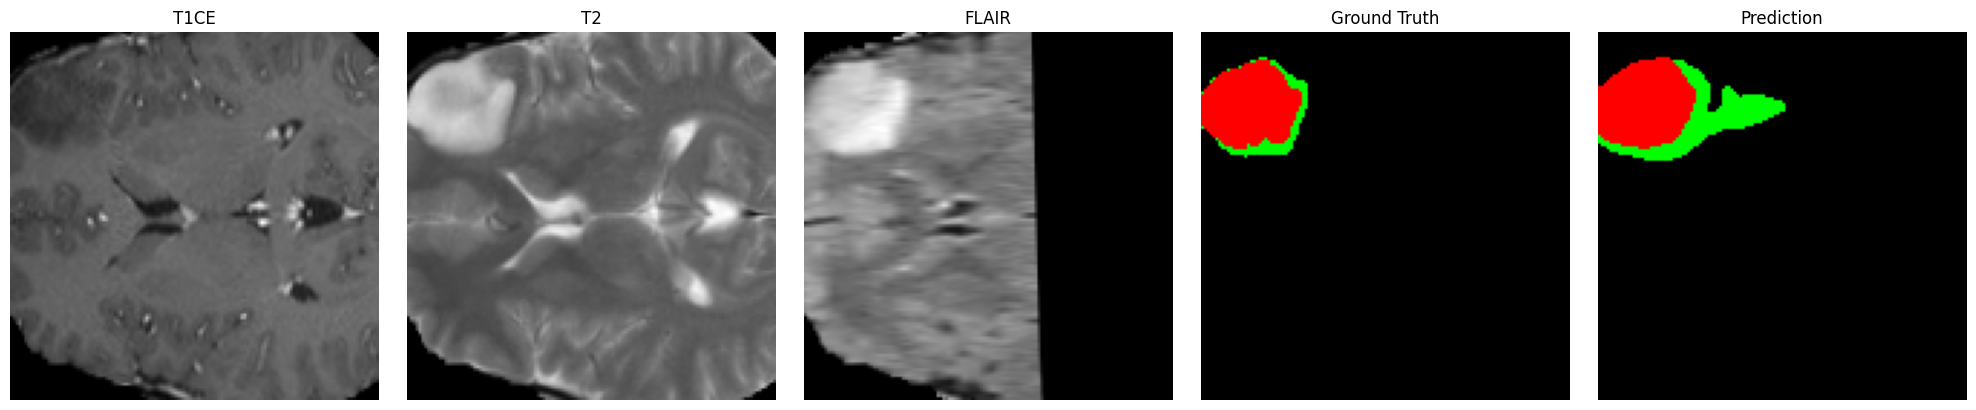

2026-06-30 16:39:58,096 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_273
2026-06-30 16:39:58,251 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_annealing_3.pth with epochs: 133
2026-06-30 16:40:02,592 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_273/BraTS20_Training_273_t1ce.nii
2026-06-30 16:40:02,593 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_273/BraTS20_Training_273_t2.nii
2026-06-30 16:40:02,593 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_273/BraTS20_Training_273_flair.nii
2026-06-30 16:40:02,594 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_273/BraTS20_Training_273_seg.nii


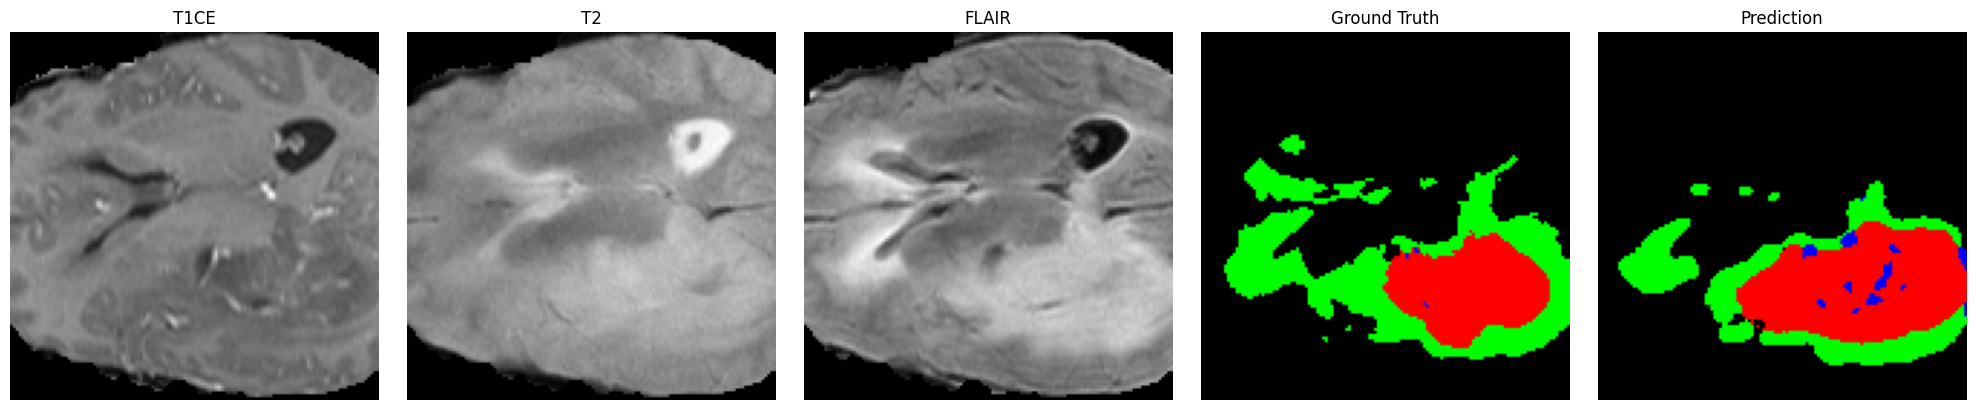

2026-06-30 16:40:12,777 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_324
2026-06-30 16:40:12,932 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_annealing_3.pth with epochs: 133
2026-06-30 16:40:17,795 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_324/BraTS20_Training_324_t1ce.nii
2026-06-30 16:40:17,796 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_324/BraTS20_Training_324_t2.nii
2026-06-30 16:40:17,797 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_324/BraTS20_Training_324_flair.nii
2026-06-30 16:40:17,798 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_324/BraTS20_Training_324_seg.nii


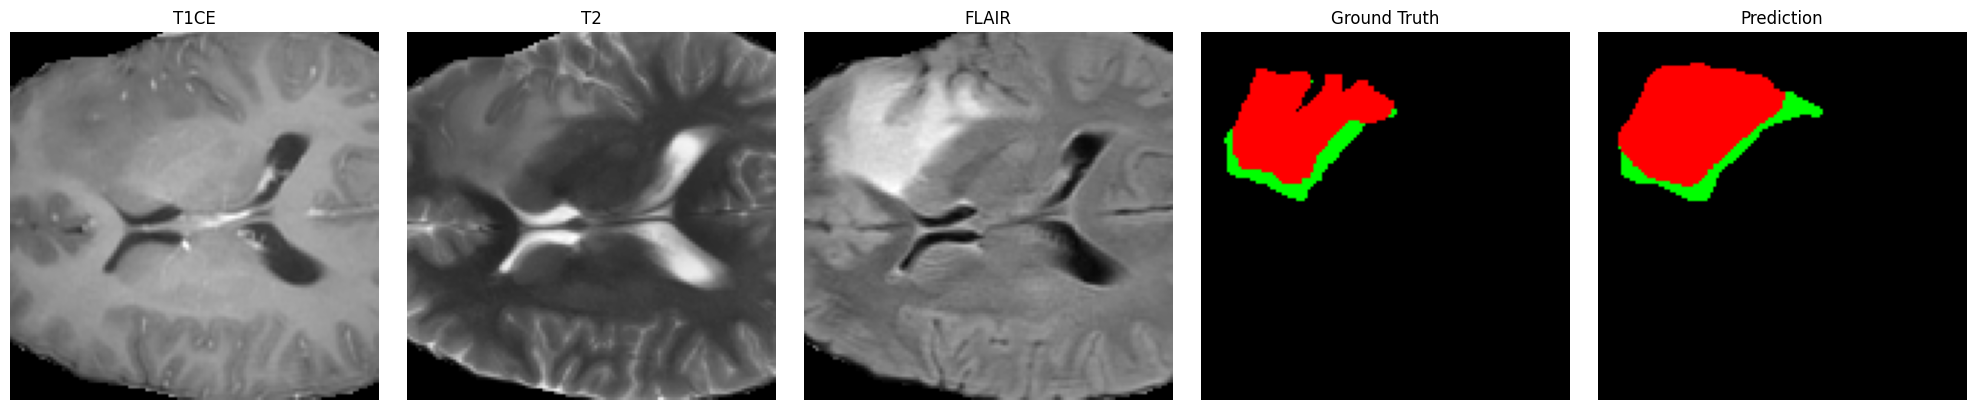

2026-06-30 16:40:27,785 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_327
2026-06-30 16:40:27,972 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_annealing_3.pth with epochs: 133
2026-06-30 16:40:33,181 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_327/BraTS20_Training_327_t1ce.nii
2026-06-30 16:40:33,182 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_327/BraTS20_Training_327_t2.nii
2026-06-30 16:40:33,183 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_327/BraTS20_Training_327_flair.nii
2026-06-30 16:40:33,183 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_327/BraTS20_Training_327_seg.nii


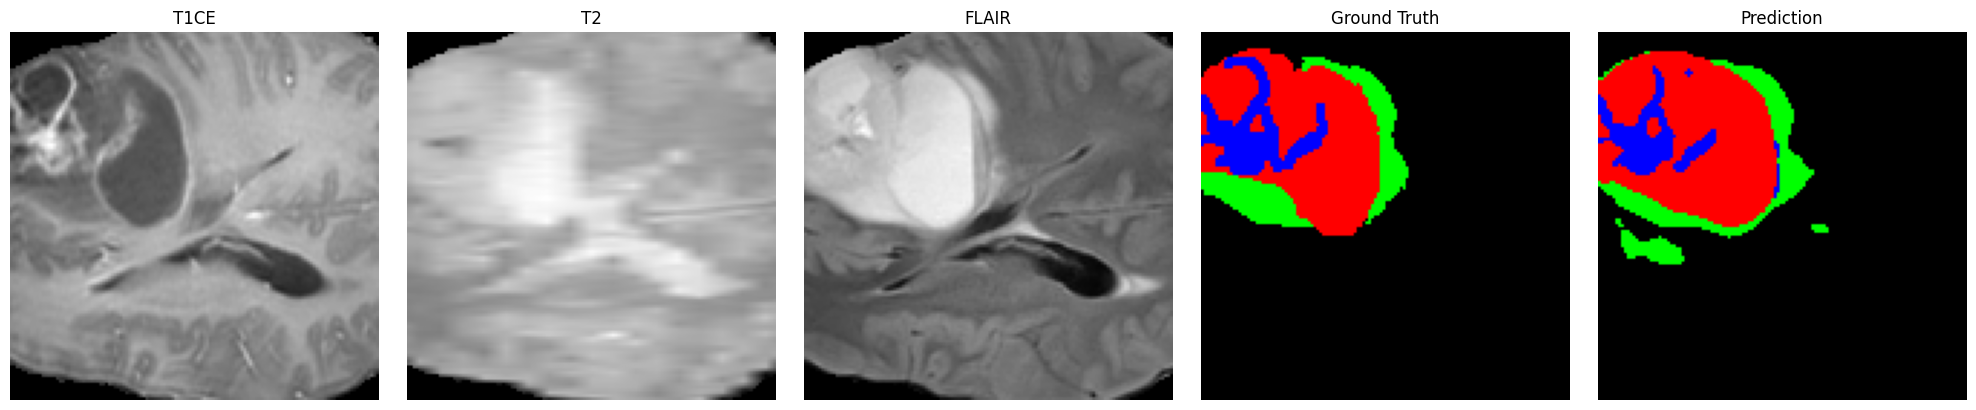

2026-06-30 16:40:43,150 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_342
2026-06-30 16:40:43,314 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_annealing_3.pth with epochs: 133
2026-06-30 16:40:47,800 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_342/BraTS20_Training_342_t1ce.nii
2026-06-30 16:40:47,801 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_342/BraTS20_Training_342_t2.nii
2026-06-30 16:40:47,802 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_342/BraTS20_Training_342_flair.nii
2026-06-30 16:40:47,803 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_342/BraTS20_Training_342_seg.nii


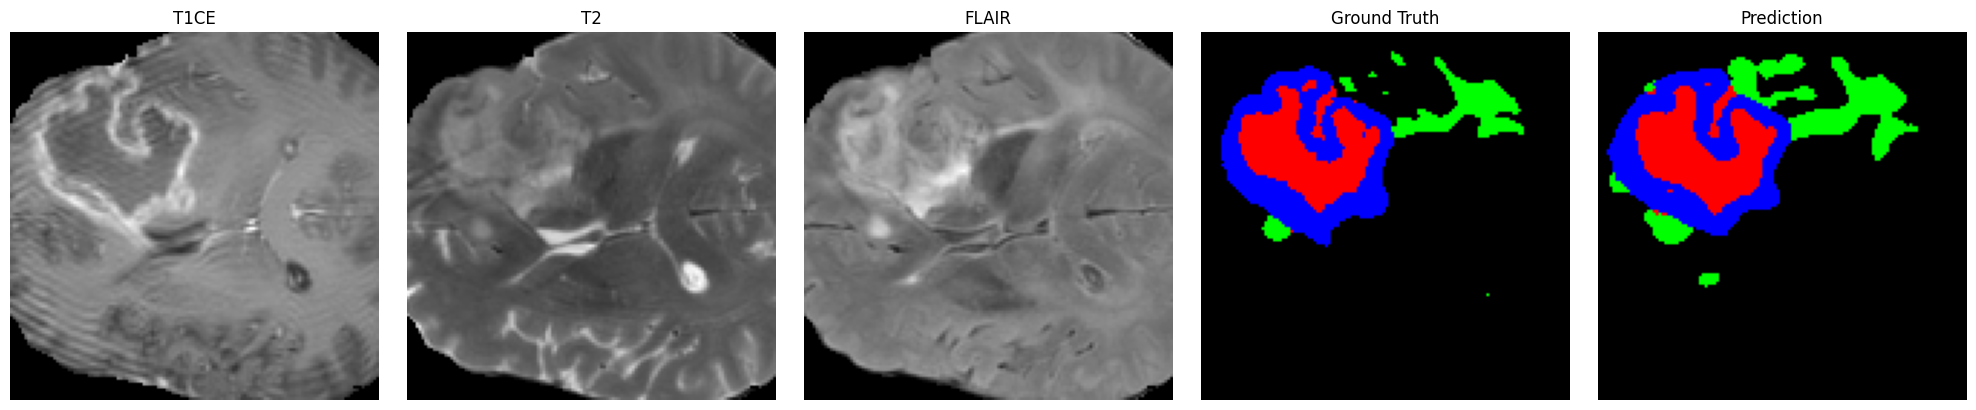

2026-06-30 16:40:57,659 | INFO | src.utils.logger | Starting prediction on RMI folder: data/raw/training/BraTS20_Training_351
2026-06-30 16:40:57,827 | DEBUG | src.utils.logger | Loaded checkpoint from trained_models/best_annealing_3.pth with epochs: 133
2026-06-30 16:41:02,718 | INFO | src.utils.logger | T1CE: data/raw/training/BraTS20_Training_351/BraTS20_Training_351_t1ce.nii
2026-06-30 16:41:02,719 | INFO | src.utils.logger | T2:   data/raw/training/BraTS20_Training_351/BraTS20_Training_351_t2.nii
2026-06-30 16:41:02,720 | INFO | src.utils.logger | FLAIR:data/raw/training/BraTS20_Training_351/BraTS20_Training_351_flair.nii
2026-06-30 16:41:02,721 | INFO | src.utils.logger | SEG:  data/raw/training/BraTS20_Training_351/BraTS20_Training_351_seg.nii


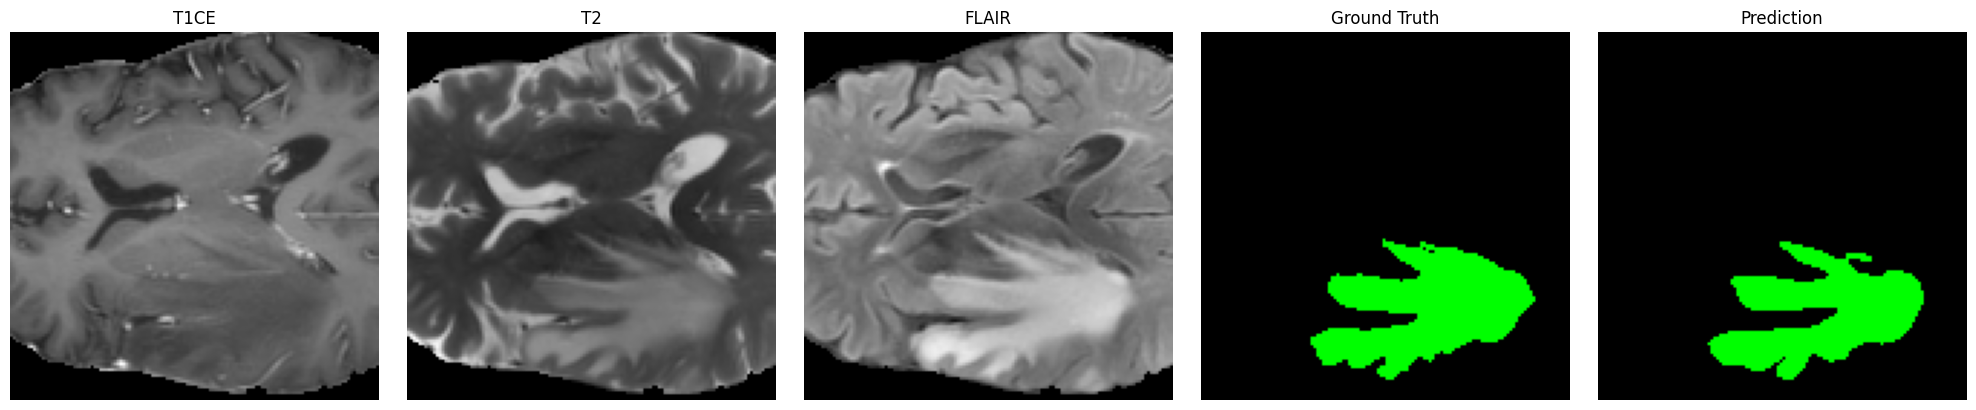

In [ ]:
# @title Predict - Annealing

main()